# Part 2 · v1 — Does the Sirolly–Ma–Kanoria–Sethi network detector work in a simulated market?

**Method.** Sirolly, Ma, Kanoria & Sethi (2026), *Network-Based Detection of Wash Trading* (Polymarket data),
Section 5.1, Algorithms 1 and 2, implemented as written:

| Part | Content | Parameters (paper) |
|---|---|---|
| Part I | position-closing initial score $x^{(0)}_i=\sum_m s^m_i\,\mathbb 1\{Q^m_i>0\}$; a closure is a terminal contraction to ≤ c × the maximum position since the previous closure | c = 0.005 |
| Part II | $x^{(k)} = \tfrac12\big(x^{(0)} + Bx^{(k-1)}\big)$, where $b_{ij}$ = share of i's volume traded with j | tol = 1e-5 |
| Algorithm 1 | flag trades with $\min(x_i,x_j)\ge\theta$ | θ = 0.9 |
| Algorithm 2 (Part III) | pick θ* in $[0.8, 0.99]$ minimizing relative spillover $Y(\theta)$, subject to $Y\le 0.1$, with slack ζ | ζ = 0.001 |

**Two things the paper did not need but a batch-auction simulator does**

- **Counterparty pairing.** A uniform-price batch clear does not record who traded with whom. Rule used:
  **pro-rata within each clear** (buy leg $b$ × sell leg $s$ is assigned $bs/Q$). It is exact whenever one side of
  the clear has a single wallet; ambiguous clears carry 0.000 (thin) / 0.003 (thick) of volume on this platform.
- **Evaluation.** The paper has **no ground truth** on real data. Here Part 1 knows exactly who is wash trading,
  so true precision / recall / FPR can be computed. Trade level is **volume-weighted** (the paper's own unit,
  "share of volume flagged"); a wallet counts as flagged if it has ≥ 1 flagged trade (the paper's convention).

**The one deliberate adaptation (switchable).** With a single asset, $x^{(0)}$ collapses to the binary
$\mathbb 1\{Q_i>0\}$ (`n_windows=1`, the default and the literal formula). `n_windows=K` splits time into K
windows used as pseudo-markets for the volume weighting.

The detector reads **only** `observable/trades.csv` (the smoke test runs it with `labels/` physically removed).
Data: `washtrade/v3/data/ds_v3`, 2 backgrounds × 9 scenarios × 10 seeds = 180 runs.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

def _find_root(start):
    d = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(d, "marketsim")) and os.path.isdir(os.path.join(d, "capstone codes")):
            return d
        p = os.path.dirname(d)
        if p == d:
            return None
        d = p

ROOT = _find_root(os.getcwd())
assert ROOT, "repo root not found"
for p in (ROOT, os.path.join(ROOT, "capstone codes")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from detection.v1 import DetectorConfig, detect, evaluate, sweep, stationary, row_normalize
from detection.v1.evaluate import attach_truth
from detection.v1.threshold import r_scores, spillover_curve
from detection.v1 import experiment as X
from washtrade.v3.export import load_observable, load_labels, load_meta
from washtrade.v3 import scenarios as S

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
DATA = os.path.join(ROOT, "capstone codes", "washtrade", "v3", "data", "ds_v3")
OUT = os.path.join(DATA, "detection_v1")
ORDER = list(S.SCENARIOS)

if not os.path.exists(os.path.join(OUT, "results.csv")):
    res, ws, ps = X.run_dataset(DATA)
    os.makedirs(OUT, exist_ok=True)
    res.to_csv(os.path.join(OUT, "results.csv"), index=False)
    ws.to_csv(os.path.join(OUT, "wallet_scores.csv"), index=False)
    ps.to_csv(os.path.join(OUT, "pair_scores.csv"), index=False)
res = pd.read_csv(os.path.join(OUT, "results.csv"))
ws = pd.read_csv(os.path.join(OUT, "wallet_scores.csv"))
ps = pd.read_csv(os.path.join(OUT, "pair_scores.csv"))
for df in (res, ws, ps):
    df["scenario"] = pd.Categorical(df["scenario"], ORDER, ordered=True)
print(res.groupby("config").size().rename("runs per config").to_string())

config
no_propagation    180
paper             180
theta_hi_1        180
windows10         180


## A. Walking through one run

The first `thin × triad_gap5` seed for which Algorithm 2 selects a threshold: one wash triangle, legs 5 steps apart,
a few interceptions.

In [2]:
pick = res[(res.config == "paper") & (res.background == "thin") & (res.scenario == "triad_gap5") & res.alg2_detects].iloc[0]
RID = pick.run_id
rdir = os.path.join(DATA, "runs", RID)
trades = load_observable(rdir)["trades"]
labels = load_labels(rdir)
det = detect(trades, DetectorConfig(), horizon=load_meta(rdir)["config"]["sim_time"])
pairs, wallets = attach_truth(det, labels)
print(RID)
print("graph:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in det.stats.items()})
print(f"propagation converged in {det.n_iter} iterations | theta* = {det.theta_star:.4f}")
wallets.sort_values("x", ascending=False)[["is_wash", "x0", "x", "r", "n_closures", "volume", "degree", "flag_fixed", "flag_star"]]

thin__triad_gap5__s001
graph: {'n_clears': 85, 'n_ambiguous_clears': 0, 'ambiguous_volume_share': 0.0, 'self_pair_qty': 0.0, 'n_wallets': 16, 'n_edges': 22, 'total_volume': 85.0}
propagation converged in 14 iterations | theta* = 0.9342


,is_wash,x0,x,r,n_closures,volume,degree,flag_fixed,flag_star
wallet,,,,,,,,,
w004,True,1.0,0.989584,0.981036,2,45.0,2,True,True
w002,True,1.0,0.981036,0.981036,22,45.0,4,True,True
w000,True,1.0,0.977216,0.977216,22,45.0,5,True,True
w010,False,1.0,0.934213,0.934213,1,2.0,2,True,True
w005,False,1.0,0.759637,0.759637,1,3.0,3,False,False
w013,False,1.0,0.736243,0.736243,1,3.0,3,False,False
w015,False,1.0,0.614380,0.307186,1,2.0,2,False,False
w003,False,0.0,0.320173,0.320173,0,3.0,3,False,False
w001,False,0.0,0.307186,0.307186,0,1.0,1,False,False


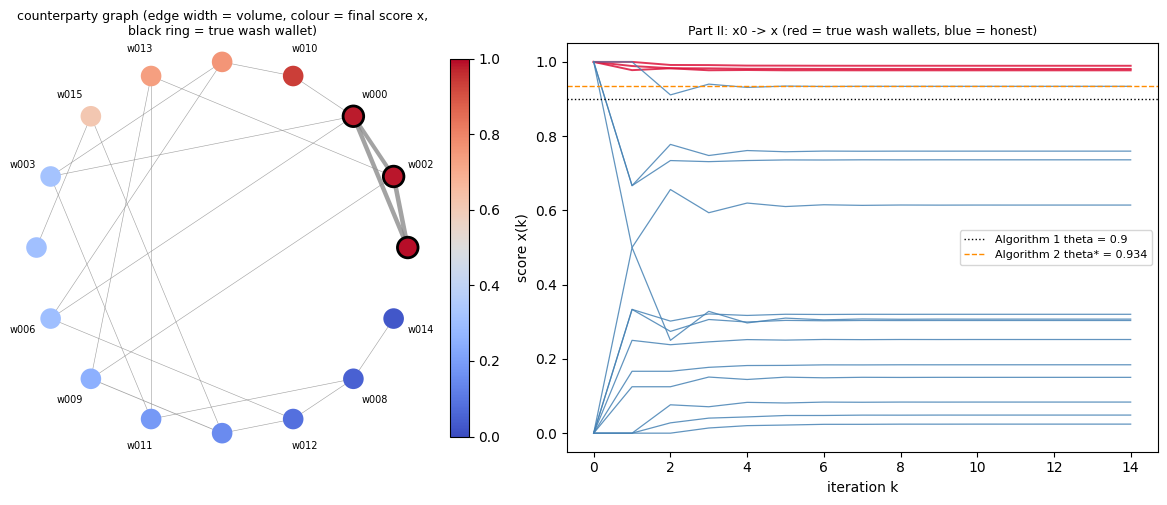

In [3]:
def draw_graph(det, truth, ax, title):
    n = len(det.index)
    x = det.wallets["x"].to_numpy()
    order = np.argsort(-x)
    ang = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = np.zeros((n, 2)); pos[order] = np.c_[np.cos(ang), np.sin(ang)]
    iu, ju = np.nonzero(np.triu(det.V, 1)); w = det.V[iu, ju]
    for i, j, v in zip(iu, ju, w):
        ax.plot(*zip(pos[i], pos[j]), color="0.55", lw=0.3 + 3.0 * v / w.max(), zorder=1, alpha=.8)
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=x, cmap="coolwarm", vmin=0, vmax=1, s=220, zorder=2,
                    edgecolors=np.where(truth, "k", "none"), linewidths=2)
    for k, wlt in enumerate(det.index):
        ax.annotate(wlt, pos[k] * 1.16, ha="center", va="center", fontsize=7)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal"); ax.axis("off")
    return sc

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw=dict(width_ratios=[1, 1.25]))
sc = draw_graph(det, wallets["is_wash"].to_numpy(), axes[0],
                "counterparty graph (edge width = volume, colour = final score x,\nblack ring = true wash wallet)")
plt.colorbar(sc, ax=axes[0], fraction=.04)

H = det.history
for k, wlt in enumerate(det.index):
    tw = wallets.loc[wlt, "is_wash"]
    axes[1].plot(range(len(H)), H[:, k], color="crimson" if tw else "steelblue", lw=1.4 if tw else 0.9, alpha=.85)
axes[1].axhline(0.9, color="k", ls=":", lw=1, label="Algorithm 1 theta = 0.9")
axes[1].axhline(det.theta_star, color="darkorange", ls="--", lw=1, label=f"Algorithm 2 theta* = {det.theta_star:.3f}")
axes[1].set_xlabel("iteration k"); axes[1].set_ylabel("score x(k)")
axes[1].set_title("Part II: x0 -> x (red = true wash wallets, blue = honest)", fontsize=9)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**The paper's two propositions (Appendix C), checked on this real graph** — they double as a test that $B$ is built
correctly. Prop. 1: the iteration converges to the unique solution of $(I-\tfrac12 B)x=\tfrac12x^{(0)}$.
Prop. 2: $v^\top x^{(k)}$ is conserved across iterations, which holds only if $B$ is built from **symmetric** pair volumes.

In [4]:
x_closed = stationary(det.history[0], row_normalize(det.V))
v = det.V.sum(axis=1)
cons = det.history @ v
print(f"Prop 1: max |x_iter - x_closed| = {np.max(np.abs(det.wallets['x'].to_numpy() - x_closed)):.2e}  (tol 1e-5 relative)")
print(f"Prop 2: v'x(k) over k ranges {cons.min():.10f} .. {cons.max():.10f}")

Prop 1: max |x_iter - x_closed| = 3.42e-06  (tol 1e-5 relative)
Prop 2: v'x(k) over k ranges 145.0000000000 .. 145.0000000000


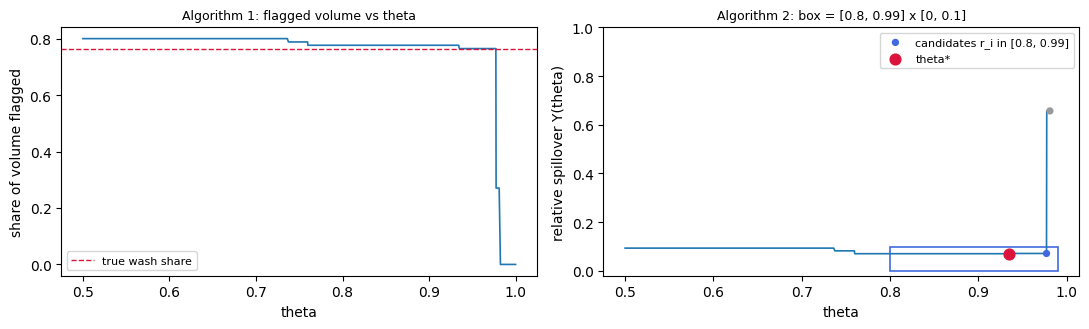

trade_fixed_precision     0.985
trade_fixed_recall        1.000
trade_fixed_fpr           0.050
trade_star_precision      0.985
trade_star_recall         1.000
trade_star_fpr            0.050
wallet_fixed_precision    0.750
wallet_fixed_recall       1.000
trade_avg_precision       1.000
wallet_roc_auc            1.000
dtype: float64

In [5]:
r = r_scores(det.wallets["x"].to_numpy(), det.V)
grid = np.unique(np.r_[np.linspace(0.5, 1.0, 201), r[(r >= .5)]])
Y = spillover_curve(r, det.V, grid)
flag_share = [pairs.loc[pairs.score >= th, "qty"].sum() / pairs.qty.sum() for th in grid]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(grid, flag_share, lw=1.2); axes[0].axhline(pairs.loc[pairs.is_wash, "qty"].sum() / pairs.qty.sum(), color="crimson", ls="--", lw=1, label="true wash share")
axes[0].set_xlabel("theta"); axes[0].set_ylabel("share of volume flagged"); axes[0].legend(fontsize=8)
axes[1].plot(grid, Y, lw=1.2)
axes[1].add_patch(plt.Rectangle((0.8, 0), 0.19, 0.1, fill=False, ec="royalblue", lw=1.2))
tab = det.threshold_table
axes[1].scatter(tab.theta, tab.Y, s=18, c=np.where(tab.feasible, "royalblue", "0.6"), zorder=3, label="candidates r_i in [0.8, 0.99]")
if np.isfinite(det.theta_star):
    axes[1].scatter([det.theta_star], [tab.set_index("theta").loc[det.theta_star, "Y"]], s=60, c="crimson", zorder=4, label="theta*")
axes[1].set_ylim(-0.02, 1); axes[1].set_xlabel("theta"); axes[1].set_ylabel("relative spillover Y(theta)")
axes[1].legend(fontsize=8); axes[0].set_title("Algorithm 1: flagged volume vs theta", fontsize=9)
axes[1].set_title("Algorithm 2: box = [0.8, 0.99] x [0, 0.1]", fontsize=9)
plt.tight_layout(); plt.show()

ev = evaluate(det, labels)
pd.Series({k: ev[k] for k in ["trade_fixed_precision", "trade_fixed_recall", "trade_fixed_fpr",
                              "trade_star_precision", "trade_star_recall", "trade_star_fpr",
                              "wallet_fixed_precision", "wallet_fixed_recall", "trade_avg_precision", "wallet_roc_auc"]}).round(3)

In this run one honest wallet trades with the wash triangle, gets pulled above both thresholds, and is flagged —
a first look at where false positives come from (Section F).

## B. Main results: the paper's algorithm (`paper` config) on 9 scenarios × 2 backgrounds

Each cell is the mean over 10 seeds. Precision is undefined (NaN, excluded from the mean) in runs where nothing is
flagged; `A2 detects` = share of runs in which Algorithm 2 returns a finite θ*.

In [6]:
def table(cfg):
    g = (res[res.config == cfg].groupby(["background", "scenario"], observed=True)
         .agg(**{"A1 P": ("trade_fixed_precision", "mean"), "A1 R": ("trade_fixed_recall", "mean"),
                 "A1 FPR": ("trade_fixed_fpr", "mean"),
                 "A1 wallet P": ("wallet_fixed_precision", "mean"), "A1 wallet R": ("wallet_fixed_recall", "mean"),
                 "A2 detects": ("alg2_detects", "mean"), "A2 P": ("trade_star_precision", "mean"),
                 "A2 R": ("trade_star_recall", "mean"), "A2 FPR": ("trade_star_fpr", "mean"),
                 "AP (trades)": ("trade_avg_precision", "mean"), "AUC (wallets)": ("wallet_roc_auc", "mean")}))
    return g.round(2)

main = table("paper")
main

A1 P  A1 R  A1 FPR  A1 wallet P  A1 wallet R  A2 detects  A2 P  A2 R  A2 FPR  AP (trades)  AUC (wallets)
background scenario                                                                                                              
thick      control        NaN   NaN    0.00          NaN          NaN         0.0   NaN   NaN    0.00          NaN            NaN
           triad         1.00  1.00    0.00         0.96         1.00         0.7  1.00   0.7    0.00         1.00           1.00
           dyad          1.00  0.90    0.00         0.94         0.90         0.6  1.00   0.6    0.00         0.99           0.98
           triad_gap5    0.99  1.00    0.01         0.91         1.00         0.0   NaN   0.0    0.00         0.99           0.99
           triad_gap20    NaN  0.00    0.00          NaN         0.00         0.0   NaN   0.0    0.00         0.92           0.98
           triad_camo    0.98  0.80    0.02         0.97         0.80         0.0   NaN   0.0    0.00         0.90           0.88
           triad_lowint  1.00  1.00    0.00         1.00         1.00         0.3  0.97   0.3    0.00         1.00           1.00
           two_groups    1.00  1.00    0.00         0.97         1.00         1.0  1.00   0.8    0.01         1.00           1.00
           hard          0.77  0.82    0.14         0.69         0.84         0.0   NaN   0.0    0.00         0.84           0.93
thin       control       0.00   NaN    0.02         0.00          NaN         0.0   NaN   NaN    0.00          NaN            NaN
           triad         0.99  1.00    0.04         0.90         1.00         0.5  0.98   0.5    0.07         1.00           0.98
           dyad          0.99  1.00    0.05         0.88         1.00         0.5  0.98   0.5    0.08         1.00           0.98
           triad_gap5    0.99  1.00    0.03         0.91         1.00         0.9  1.00   0.9    0.02         0.99           0.99
           triad_gap20   0.98  0.60    0.03         0.89         0.60         0.0   NaN   0.0    0.00         0.93           0.90
           triad_camo    0.98  1.00    0.11         0.88         1.00         0.9  0.97   0.9    0.15         0.98           0.99
           triad_lowint  1.00  0.90    0.01         0.97         0.90         0.3  0.99   0.3    0.01         0.99           0.99
           two_groups    1.00  1.00    0.00         1.00         1.00         0.5  0.99   0.5    0.04         1.00           1.00
           hard          0.94  0.95    0.28         0.84         0.96         0.5  0.92   0.5    0.19         0.95           0.96

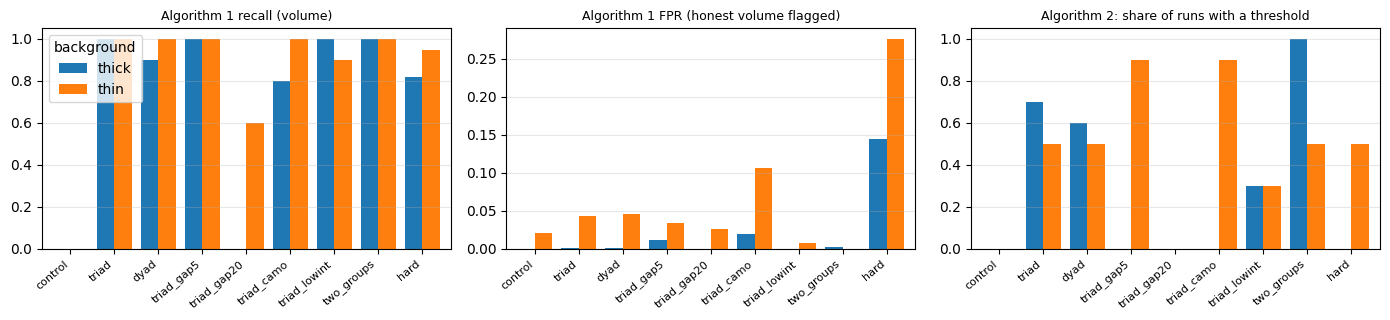

In [7]:
p = res[res.config == "paper"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3), sharey=False)
for ax, (col, t) in zip(axes, [("trade_fixed_recall", "Algorithm 1 recall (volume)"),
                               ("trade_fixed_fpr", "Algorithm 1 FPR (honest volume flagged)"),
                               ("alg2_detects", "Algorithm 2: share of runs with a threshold")]):
    p.groupby(["scenario", "background"], observed=True)[col].mean().unstack().reindex(ORDER).plot.bar(ax=ax, width=.8, legend=(ax is axes[0]))
    ax.set_title(t, fontsize=9); ax.set_xlabel(""); ax.grid(axis="y", alpha=.3); ax.tick_params(axis="x", rotation=40, labelsize=8)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
plt.tight_layout(); plt.show()

## C. Network propagation is necessary: the `no_propagation` ablation (final score = $x^{(0)}$)

In this market **22–37% of honest ZIs close a position at least once** (random buy/sell with positions hovering
around zero), so on the closing signal alone they score 1, just like wash wallets. The network step redistributes
scores along counterparties: a wallet keeps a high score only if it trades with wallets that also close.

is_wash,honest: share with x0=1,wash: share with x0=1
background,,
thick,0.36,0.97
thin,0.25,0.98


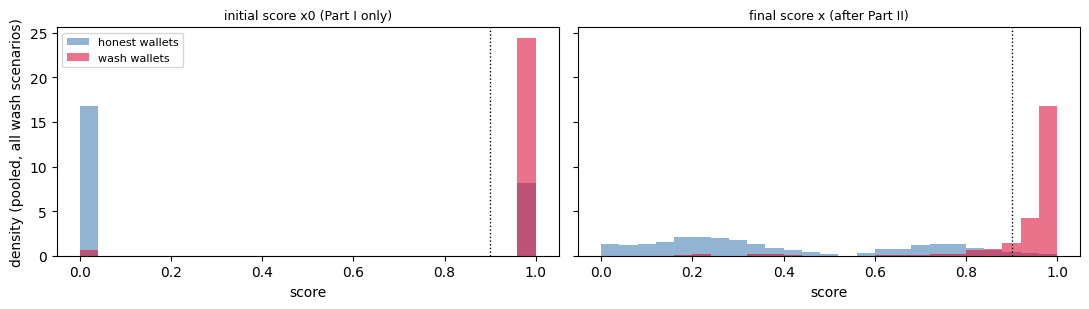

trade_fixed_precision  trade_fixed_recall  trade_fixed_fpr  wallet_fixed_precision  wallet_fixed_fpr  trade_avg_precision  wallet_roc_auc
config         background                                                                                                                                           
no_propagation thick                       0.795               0.955            0.171                   0.278             0.299                0.814           0.833
               thin                        0.948               0.950            0.172                   0.621             0.195                0.939           0.891
paper          thick                       0.961               0.815            0.023                   0.919             0.013                0.955           0.970
               thin                        0.983               0.931            0.068                   0.911             0.037                0.980           0.976

In [8]:
closed = ws[(ws.config == "paper")].assign(closed=lambda d: d.x0 >= 1)
display(closed.groupby(["background", "is_wash"])["closed"].mean().unstack().rename(columns={False: "honest: share with x0=1", True: "wash: share with x0=1"}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
bins = np.linspace(0, 1, 26)
for ax, col, t in ((axes[0], "x0", "initial score x0 (Part I only)"), (axes[1], "x", "final score x (after Part II)")):
    sub = ws[(ws.config == "paper") & (ws.scenario != "control")]
    ax.hist(sub.loc[~sub.is_wash, col], bins=bins, alpha=.6, label="honest wallets", color="steelblue", density=True)
    ax.hist(sub.loc[sub.is_wash, col], bins=bins, alpha=.6, label="wash wallets", color="crimson", density=True)
    ax.axvline(0.9, color="k", ls=":", lw=1); ax.set_title(t, fontsize=9); ax.set_xlabel("score")
axes[0].legend(fontsize=8); axes[0].set_ylabel("density (pooled, all wash scenarios)")
plt.tight_layout(); plt.show()

cmp = (res[res.config.isin(["paper", "no_propagation"]) & (res.scenario != "control")]
       .groupby(["config", "background"])[["trade_fixed_precision", "trade_fixed_recall", "trade_fixed_fpr",
                                           "wallet_fixed_precision", "wallet_fixed_fpr", "trade_avg_precision", "wallet_roc_auc"]]
       .mean().round(3))
cmp

In [9]:
ctrl = (res[res.config.isin(["paper", "no_propagation"]) & (res.scenario == "control")]
        .groupby(["config", "background"])[["trade_fixed_fpr", "wallet_fixed_fpr", "wallet_fixed_n_flagged", "alg2_detects"]].mean().round(3))
print("Negative control (all ZI) -- anything flagged is a false positive:")
ctrl

Negative control (all ZI) -- anything flagged is a false positive:


trade_fixed_fpr  wallet_fixed_fpr  wallet_fixed_n_flagged  alg2_detects
config         background                                                                         
no_propagation thick                 0.094             0.242                     7.2           0.0
               thin                  0.076             0.141                     1.7           0.0
paper          thick                 0.000             0.000                     0.0           0.0
               thin                  0.021             0.040                     0.5           0.0

## D. Why Algorithm 2 often declines to flag anything

Algorithm 2 returns θ* only if some candidate lies in $[\underline\theta,\bar\theta]=[0.8,0.99]$ with $Y\le 0.1$;
otherwise it concludes "no wash trading". Diagnosing each run shows two very different failure modes:

In [10]:
diag = []
for row in res[(res.config == "paper") & (res.scenario != "control")].itertuples():
    rd = os.path.join(DATA, "runs", row.run_id)
    d = detect(load_observable(rd)["trades"], DetectorConfig(), horizon=load_meta(rd)["config"]["sim_time"])
    _, wl = attach_truth(d, load_labels(rd))
    rr = r_scores(d.wallets["x"].to_numpy(), d.V); tw = wl["is_wash"].to_numpy()
    cand = np.unique(rr[(rr >= .8) & (rr <= .99)])
    reason = ("finds theta*" if np.isfinite(d.theta_star)
              else "no candidate r in [0.8, 0.99]" if len(cand) == 0 else "every candidate has Y > 0.1")
    Yc = spillover_curve(rr, d.V, cand)
    diag.append(dict(background=row.background, scenario=row.scenario, reason=reason,
                     lowest_wash_r=rr[tw].min(), highest_honest_r=rr[~tw].max(),
                     min_Y=np.nanmin(Yc) if len(Yc) else np.nan))
diag = pd.DataFrame(diag)
diag["scenario"] = pd.Categorical(diag["scenario"], ORDER, ordered=True)
display(pd.crosstab([diag.background, diag.scenario], diag.reason))
diag.groupby(["background", "scenario"], observed=True)[["lowest_wash_r", "highest_honest_r", "min_Y"]].median().round(3)

reason                   every candidate has Y > 0.1  finds theta*  no candidate r in [0.8, 0.99]
background scenario                                                                              
thick      triad                                   0             7                              3
           dyad                                    0             6                              4
           triad_gap5                             10             0                              0
           triad_gap20                            10             0                              0
           triad_camo                              8             0                              2
           triad_lowint                            6             3                              1
           two_groups                              0            10                              0
           hard                                   10             0                              0
thin       triad                                   0             5                              5
           dyad                                    0             5                              5
           triad_gap5                              1             9                              0
           triad_gap20                             6             0                              4
           triad_camo                              1             9                              0
           triad_lowint                            0             3                              7
           two_groups                              0             5                              5
           hard                                    5             5                              0

lowest_wash_r  highest_honest_r  min_Y
background scenario                                            
thick      triad                 0.983             0.777  0.067
           dyad                  0.983             0.781  0.065
           triad_gap5            0.929             0.844  0.222
           triad_gap20           0.839             0.859  0.500
           triad_camo            0.946             0.834  0.147
           triad_lowint          0.966             0.789  0.120
           two_groups            0.982             0.836  0.043
           hard                  0.908             0.930  0.274
thin       triad                 1.000             0.766  0.022
           dyad                  1.000             0.766  0.022
           triad_gap5            0.980             0.826  0.069
           triad_gap20           0.913             0.794  0.245
           triad_camo            0.982             0.862  0.062
           triad_lowint          1.000             0.670  0.053
           two_groups            0.993             0.776  0.017
           hard                  0.969             0.916  0.098

- **"Too clean"** (about half the thin triad / dyad / two_groups / lowint runs): the wash cluster is perfectly
  closed, its $r_i$ is **exactly 1**, above the 0.99 upper bound, while every honest $r$ is below 0.8 — so the window
  holds no candidate threshold and Algorithm 2 reports no wash trading. On real Polymarket data clusters are always
  intercepted a little and never reach 1, so the paper never met this case; in simulation, "perfect" wash trading
  slips past Algorithm 2.
- **"No clean cut"** (all thick gap5 / gap20 / hard runs, most camo runs): interceptions and camouflage create real
  trades between wash and honest wallets; the smallest spillover $Y$ is 0.15–0.5, above $\bar Y=0.1$, so Algorithm 2
  **correctly refuses** to report a cut with that much spillover.

Sensitivity: raising the upper bound to 1.0 (`theta_hi_1`) repairs only the first failure mode:

In [11]:
sens = (res[res.config.isin(["paper", "theta_hi_1"]) & (res.scenario != "control")]
        .groupby(["background", "scenario", "config"], observed=True)[["alg2_detects", "trade_star_recall", "trade_star_precision"]]
        .mean().unstack("config").round(2))
sens

alg2_detects            trade_star_recall            trade_star_precision           
config                         paper theta_hi_1             paper theta_hi_1                paper theta_hi_1
background scenario                                                                                         
thick      triad                 0.7        1.0               0.7       1.00                 1.00       1.00
           dyad                  0.6        0.9               0.6       0.90                 1.00       1.00
           triad_gap5            0.0        0.0               0.0       0.00                  NaN        NaN
           triad_gap20           0.0        0.0               0.0       0.00                  NaN        NaN
           triad_camo            0.0        0.0               0.0       0.00                  NaN        NaN
           triad_lowint          0.3        0.6               0.3       0.60                 0.97       0.99
           two_groups            1.0        1.0               0.8       0.70                 1.00       1.00
           hard                  0.0        0.0               0.0       0.00                  NaN        NaN
thin       triad                 0.5        1.0               0.5       1.00                 0.98       1.00
           dyad                  0.5        1.0               0.5       1.00                 0.98       1.00
           triad_gap5            0.9        0.9               0.9       0.90                 1.00       1.00
           triad_gap20           0.0        0.0               0.0       0.00                  NaN        NaN
           triad_camo            0.9        0.9               0.9       0.90                 0.97       0.97
           triad_lowint          0.3        0.9               0.3       0.90                 0.99       1.00
           two_groups            0.5        1.0               0.5       0.54                 0.99       1.00
           hard                  0.5        0.5               0.5       0.50                 0.92       0.92

## E. Single-asset adaptation: K time windows as pseudo-markets (`windows10`)

The paper weights by volume share across markets so that closing once by chance does not earn a full score.
Splitting time into 10 windows mimics that:

x_wash_mean  x_honest_mean  x_honest_max  trade_fixed_recall  trade_fixed_fpr  trade_avg_precision  wallet_roc_auc
config    background                                                                                                                    
paper     thick             0.926          0.413         0.859               0.815            0.023                0.955           0.970
          thin              0.960          0.343         0.805               0.931            0.068                0.980           0.976
windows10 thick             0.693          0.267         0.676               0.260            0.000                0.907           0.903
          thin              0.780          0.198         0.509               0.366            0.000                0.981           0.973

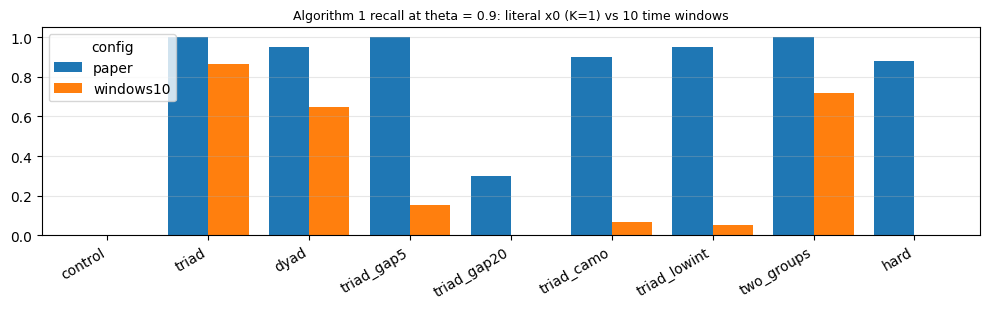

In [12]:
k = (res[res.config.isin(["paper", "windows10"]) & (res.scenario != "control")]
     .groupby(["config", "background"])[["x_wash_mean", "x_honest_mean", "x_honest_max", "trade_fixed_recall",
                                         "trade_fixed_fpr", "trade_avg_precision", "wallet_roc_auc"]].mean().round(3))
display(k)
fig, ax = plt.subplots(figsize=(10, 3.2))
(res[res.config.isin(["paper", "windows10"])].groupby(["scenario", "config"], observed=True)["trade_fixed_recall"]
    .mean().unstack().reindex(ORDER).plot.bar(ax=ax, width=.8))
ax.set_title("Algorithm 1 recall at theta = 0.9: literal x0 (K=1) vs 10 time windows", fontsize=9)
ax.set_xlabel(""); ax.grid(axis="y", alpha=.3); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

Windowing lowers **both** honest and wash scores (wash groups do not close in every window, especially at low
intensity, with interception or with camouflage). Ranking quality (AP, AUC) is unchanged on clean scenarios and
slightly worse on camo/hard, while recall at the fixed θ = 0.9 collapses. **In this market the paper's literal
formula (K = 1) is the better choice**: only 22–37% of honest ZIs ever close, so the problem the cross-market
weighting guards against is mild here.

## F. Where the false positives come from

At the fixed θ = 0.9, how much of the wrongly flagged honest volume sits on **edges between an honest wallet and a
wash wallet** (interceptions, or ordinary trades with camouflage wallets):

In [13]:
wl_all = ws[ws.config == "paper"][["run_id", "wallet", "is_wash"]]
key = wl_all.set_index(["run_id", "wallet"])["is_wash"]
fp = ps[(ps.config == "paper") & ps.flag_fixed & ~ps.is_wash].copy()
fp["touches_wash_wallet"] = (key.reindex(list(zip(fp.run_id, fp.buyer))).to_numpy()
                             | key.reindex(list(zip(fp.run_id, fp.seller))).to_numpy())
g = fp.groupby(["background", "scenario"], observed=True).apply(
        lambda d: pd.Series(dict(fp_volume=d.qty.sum(), share_on_wash_edges=d.loc[d.touches_wash_wallet, "qty"].sum() / d.qty.sum())))
g.round(2)

fp_volume  share_on_wash_edges
background scenario                                    
thick      triad               1.0                 0.00
           dyad                1.0                 0.00
           triad_gap5          7.5                 0.87
           triad_camo         14.0                 1.00
           two_groups          2.0                 1.00
           hard              168.0                 0.98
thin       control             4.0                 0.00
           triad               6.0                 0.50
           dyad                6.0                 0.50
           triad_gap5          6.0                 1.00
           triad_gap20         6.0                 0.83
           triad_camo         23.0                 0.96
           triad_lowint        1.0                 1.00
           hard               88.5                 0.99

In scenarios with interception or camouflage (gap5 / gap20 / camo / hard), 83–100% of the wrongly flagged volume
lies on such edges; clean scenarios have almost no false-positive volume to begin with (a few units over 10 seeds).
These false positives are **victims pulled up by the wash cluster**: an honest ZI that took an exposed wash leg, or
traded normally with a camouflage wallet, has a counterparty scoring ≈ 1, and the network step lifts its own score
over the threshold. This is exactly the "spillover onto honest traders" anticipated in our design notes; it grows
with the gap and with camouflage and is most visible in `hard`. The thin background has little honest volume, so a
few wrongly flagged trades already make the FPR look large.

## G. Threshold-free view (volume-weighted precision–recall, pooled over 10 seeds)

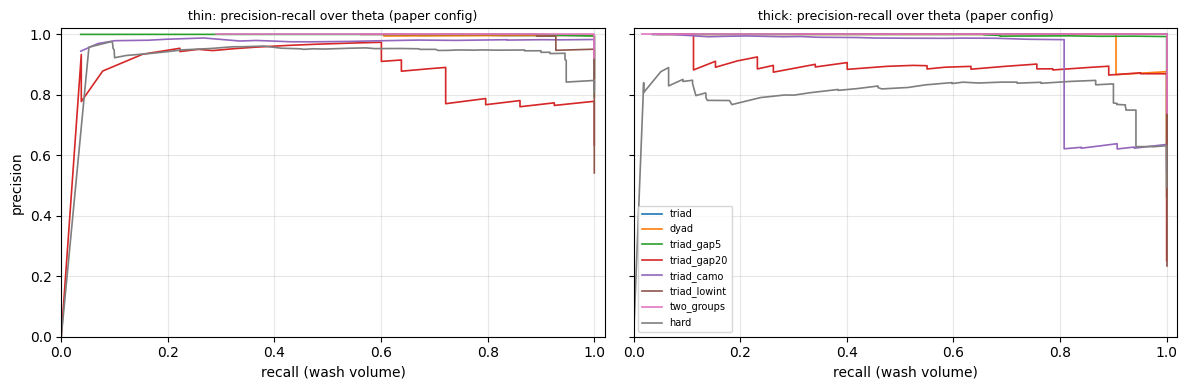

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, bg in zip(axes, ("thin", "thick")):
    for sc in ORDER[1:]:
        sub = ps[(ps.config == "paper") & (ps.background == bg) & (ps.scenario == sc)]
        cv = sweep(sub.score, sub.is_wash, sub.qty)
        ax.plot(cv.recall, cv.precision, lw=1.2, label=sc)
    ax.set_title(f"{bg}: precision-recall over theta (paper config)", fontsize=9)
    ax.set_xlabel("recall (wash volume)"); ax.grid(alpha=.3); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("precision"); axes[1].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

---
## Summary

**Findings (10 seeds, 180 runs)**

1. **The paper's algorithm transfers to this simulated platform.** On clean scenarios (triad / dyad / two_groups /
   lowint), Algorithm 1 at θ = 0.9 reaches volume-weighted precision ≈ 0.99–1.00 and recall 0.9–1.0. In the all-ZI
   control it flags nothing in the thick background and 2% of honest volume in the thin one.
2. **Network propagation is necessary, not a refinement.** On the closing score alone, 6–36% of honest volume is
   flagged (22–37% of honest ZIs also close positions); with the network step this drops to ≤ 5% on clean scenarios.
3. **A dyad is detected as well as a triad.** The concern that with 2 wallets "the network part idles" does not hold:
   when two wallets trade only with each other, each keeps the other's score high.
4. **Algorithm 2 declines in two distinct ways in simulation**: the cluster is "too clean" (r = 1, outside the 0.99
   window) or there is "no clean cut" (interception/camouflage push Y above 0.1). The first is a window setting;
   the second is the algorithm's intended conservatism.
5. **Interception and camouflage are what make detection hard**: gap 20, camouflage in the thick background, and
   `hard` all show clearly lower recall and precision; false positives concentrate on honest wallets adjacent to
   wash wallets.
6. **Single-asset adaptation**: time-window pseudo-markets (K = 10) do not improve ranking (slightly worse on hard
   scenarios) and break the fixed threshold; the literal formula is the better fit.
7. **The pro-rata pairing rule is essentially exact**: ambiguous clears carry ≤ 0.3% of volume.

**Limitations.** Single asset; ZI-only background; ZI is the only camouflage behaviour, and in this low-activity
market camouflage wallets trade ordinarily very little; Algorithm 2's parameters (0.8, 0.99, 0.1, 0.001) were set for
Polymarket and have not been recalibrated for the simulator.

**TODO / possible next steps.** (a) Re-check the export schema, the pro-rata pairing rule and K = 1, which are working defaults; (b) sweep the gap and camouflage
strength continuously to chart detectability against how covert the wash trading is; (c) the leave-one-out message
passing mentioned in the paper's Section 5.1 as an alternative Part II; (d) make camouflage intensity tunable
(the wallets' ordinary trading rate).